In [1]:

import matplotlib.pyplot as plt
import csv
import numpy as np

import phi4Parallel

%matplotlib inline

E_max: 10
 reduced basis length = 35 and number of asymmetric states = 11
 total basis length = 46
number of entries in matrix is 1031
792 ms ± 49.1 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 11
 reduced basis length = 53 and number of asymmetric states = 20
 total basis length = 73
number of entries in matrix is 1800
810 ms ± 24.8 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 12
 reduced basis length = 73 and number of asymmetric states = 32
 total basis length = 105
number of entries in matrix is 3007
786 ms ± 24.4 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 13
 reduced basis length = 108 and number of asymmetric states = 54
 total basis length = 162
number of entries in matrix is 5289
767 ms ± 34.7 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)
E_max: 14
 reduced basis length = 151 and number of asymmetric states = 85
 total basis length = 236
number of entries in matrix is 8500
788 ms ± 40.5 ms per loop (mean ± std. dev. of 4

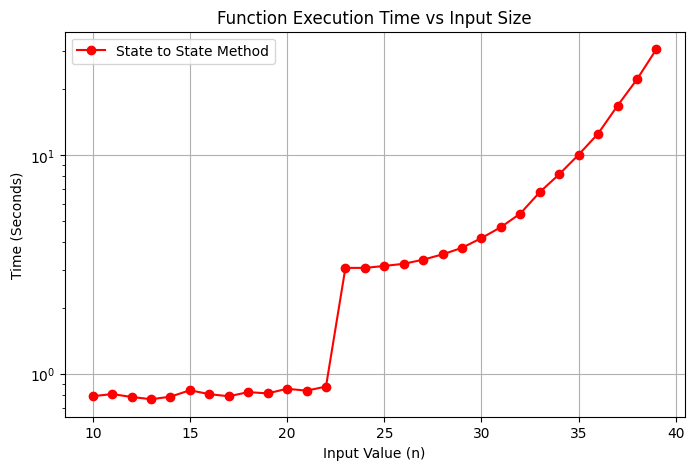

In [2]:
# 1. Preparing the parameters for the timing run, and lists for results.
g = 4*np.pi; mQ = 1.; r = 1.; mV = 1. # Hamiltonian parameters.
execution_times = []; basis_lengths = []
emax_list = range(10,40) #EMax range.

# 2. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = phi4Parallel.effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    dict_basis, hashable_basis, iterList  = phi4Parallel.basis_even(*phi4Parallel.gen_basis(lmaxeff,emax,mQ,r))
    phi4Parallel.gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.
    print(f' reduced basis length = {len(iterList)} and number of asymmetric states = {len(dict_basis)-len(iterList)}')
    print(f' total basis length = {len(dict_basis)}')
    H = phi4Parallel.transition_matrix_phi4(mQ, g, r, lmaxeff, dict_basis, hashable_basis, iterList)
    print(f'number of entries in matrix is {H.nnz}')
    # Timing: 
    duration = %timeit -o -r4 phi4Parallel.transition_matrix_phi4(mQ, g, r, lmaxeff, dict_basis, hashable_basis, iterList)
    # Add results to relevant lists.
    execution_times.append(duration.average)
    basis_lengths.append(len(dict_basis))


# 3. Export results to a CSV file
csv_filename = "phi4_statetostate_results_parallel.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, mV = {mV}, r = {r}") # To keep track of HT parameters.
    writer.writerow("EMax List")  # Writes emax list onto file header.
    writer.writerow(emax_list) # To keep track of the relevant emax's used.
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='r', label="State to State Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()
